In [1]:
%load_ext autoreload
%autoreload 2

In [133]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# from saqc import SaQC
import metpyqc as qc

from qc_func import *
from fake_data_design import *
from visualizaion_func import *

In [87]:
from crmprtd import setup_logging
import sqlalchemy as sa
from sqlalchemy.orm import Session
import sys
function_path = '../'
sys.path.append(function_path)

save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

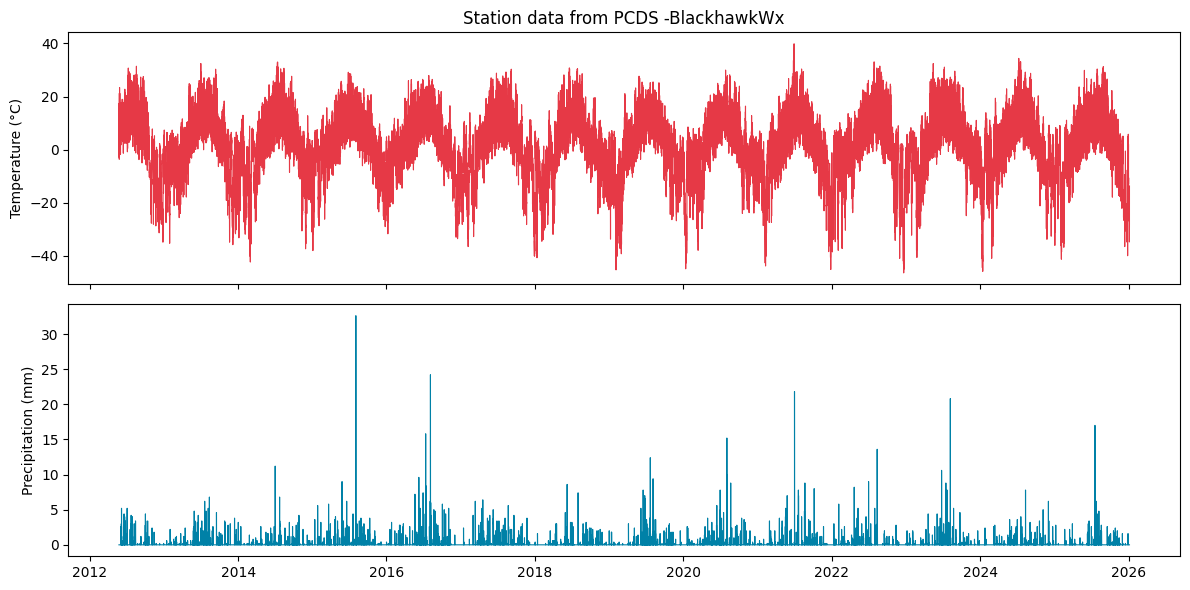

In [122]:
sql_text = sa.text("""
SELECT o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 11
AND h.station_name = 'BlackhawkWx'
AND v.net_var_name IN ('TempC', 'Rainmm')
""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

# convert time
df["obs_time"] = pd.to_datetime(df["obs_time"])

# pivot → columns = variables
df_sql = df.pivot_table(
    index="obs_time",
    columns="net_var_name",
    values="datum"
)

# rename for clarity
df_sql = df_sql.rename(columns={
    "TempC": "temp",
    "Rainmm": "precip"
})

# sort index
df_sql = df_sql.sort_index()
df_sql


plot_weather_data(df_sql, title='Station data from PCDS -BlackhawkWx')

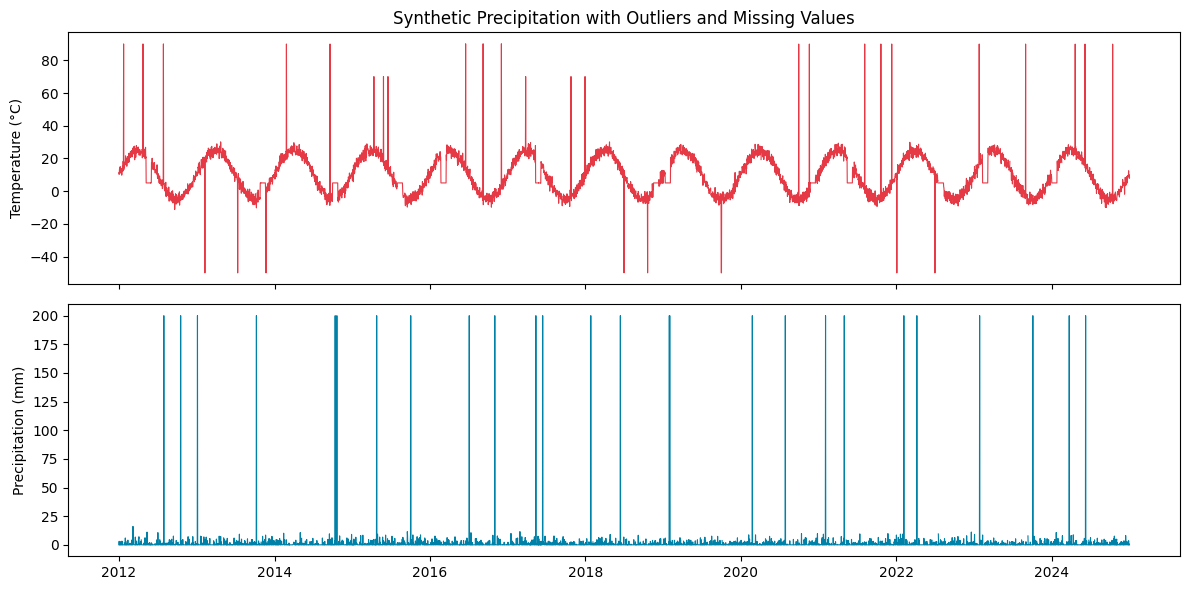

In [123]:
df_test_tas_pr = generate_climate_outlier_test_data()

plot_weather_data(
    df_test_tas_pr, title="Synthetic Precipitation with Outliers and Missing Values")

In [124]:
import numpy as np
import pandas as pd
from astropy.stats import biweight_location, biweight_scale


def temp_outlier_flags(df):

    df = df.copy()
    df["doy"] = df.index.dayofyear

    # handle leap day → merge into 365
    df.loc[df["doy"] == 366, "doy"] = 365

    mu_arr = np.full(len(df), np.nan)
    sigma_arr = np.full(len(df), np.nan)

    # loop over DOY (365 instead of 100k rows)
    for doy in range(1, 366):

        window = [(doy + d - 1) % 365 + 1 for d in range(-7, 8)]

        mask_window = df["doy"].isin(window)
        clim = df.loc[mask_window, "temp"].dropna().values

        if len(clim) < 100:
            continue

        mu = biweight_location(clim)
        sigma = biweight_scale(clim)

        if sigma == 0 or np.isnan(sigma):
            continue

        # assign to all rows of this doy
        mask_target = df["doy"] == doy
        mu_arr[mask_target] = mu
        sigma_arr[mask_target] = sigma

    z = (df["temp"].values - mu_arr) / sigma_arr

    flags = (np.abs(z) > 6) & (~np.isnan(
        z))
    return pd.Series(flags, index=df.index)


def precip_outlier_flags(df):

    df = df.copy()
    df["doy"] = df.index.dayofyear
    df.loc[df["doy"] == 366, "doy"] = 365

    p95_arr = np.full(len(df), np.nan)

    for doy in range(1, 366):

        window = [(doy + d - 1) % 365 + 1 for d in range(-14, 15)]

        mask_window = df["doy"].isin(window)
        clim = df.loc[mask_window, "precip"]
        clim = clim[clim > 0]

        if len(clim) < 20:
            continue

        p95 = np.percentile(clim, 95)

        mask_target = df["doy"] == doy
        p95_arr[mask_target] = p95

    # temperature condition
    warm = df["temp"].values > 0

    threshold = np.where(
        warm,
        2 * p95_arr,
        5 * p95_arr
    )

    flags = df["precip"].values > threshold

    return pd.Series(flags, index=df.index)

In [125]:
df_sql_daily = df_sql.resample("1D").agg({
    "precip": "sum",      # daily total
    "temp": "mean"        # daily mean temp
})

df_sql_daily["doy"] = df_sql_daily.index.dayofyear

df_sql_daily["temp_flag"] = temp_outlier_flags(df_sql_daily)
df_sql_daily["precip_flag"] = precip_outlier_flags(df_sql_daily)
df_sql_daily

net_var_name,precip,temp,doy,temp_flag,precip_flag
obs_time,,,,,
2012-05-24,0.0,9.584091,145,False,False
2012-05-25,0.0,8.605292,146,False,False
2012-05-26,0.0,11.138375,147,False,False
2012-05-27,0.0,12.723250,148,False,False
2012-05-28,0.0,13.024083,149,False,False
...,...,...,...,...,...
2026-01-01,0.0,-16.272292,1,False,False
2026-01-02,0.0,-20.965333,2,False,False
2026-01-03,0.0,-22.069875,3,False,False


In [126]:
df_test_daily = df_test_tas_pr.resample("1D").agg({
    "precip": "sum",      # daily total
    "temp": "mean"        # daily mean temp
})

df_test_daily["doy"] = df_test_daily.index.dayofyear

df_test_daily["temp_flag"] = temp_outlier_flags(df_test_daily)
df_test_daily["precip_flag"] = precip_outlier_flags(df_test_daily)
df_test_daily

,precip,temp,doy,temp_flag,precip_flag
2012-01-01,0.000000,11.251629,1,False,False
2012-01-02,3.065761,10.239796,2,False,False
2012-01-03,0.000000,12.069672,3,False,False
2012-01-04,0.000000,14.078096,4,False,False
2012-01-05,0.000000,10.821165,5,False,False
...,...,...,...,...,...
2024-12-27,3.593283,12.434383,362,False,False
2024-12-28,0.000000,8.913487,363,False,False
2024-12-29,0.844646,10.019090,364,False,False
2024-12-30,0.000000,7.827747,365,False,False


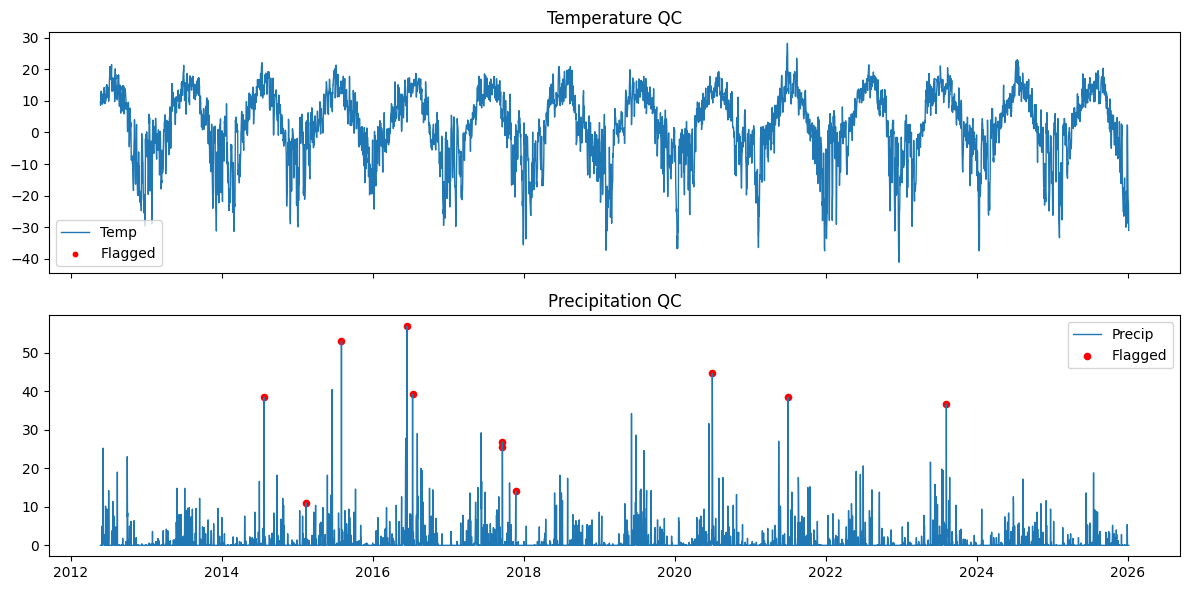

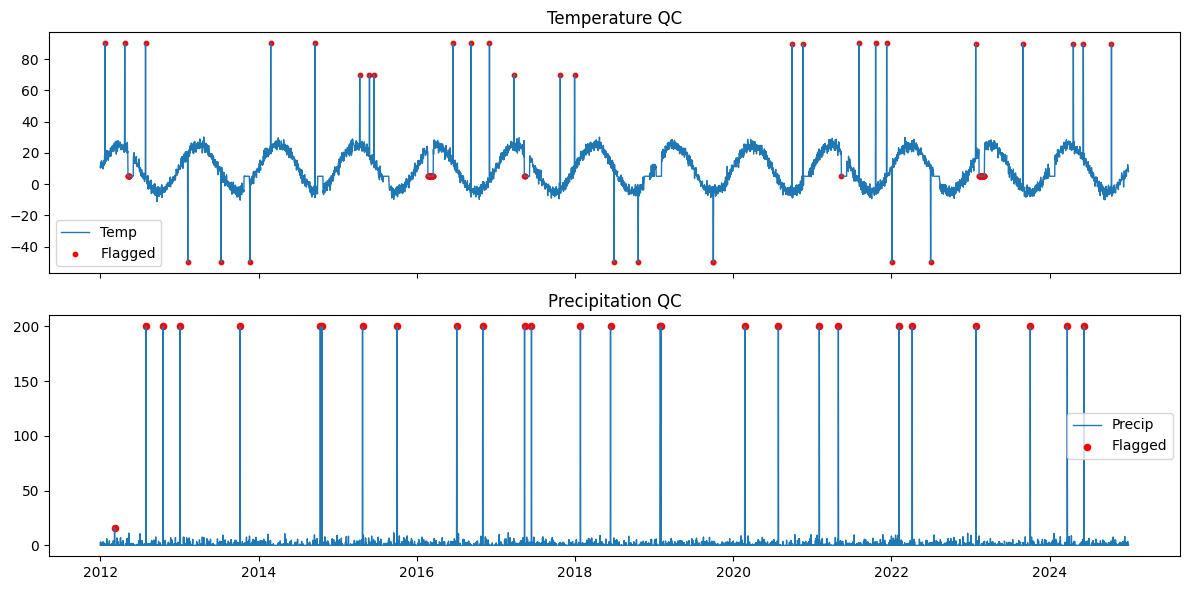

In [127]:
import matplotlib.pyplot as plt


def plot_qc_timeseries(df):

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # --- Temperature ---
    axes[0].plot(df.index, df["temp"], label="Temp", linewidth=1)
    axes[0].scatter(
        df.index[df["temp_flag"]],
        df["temp"][df["temp_flag"]],
        color="red", s=10, label="Flagged"
    )
    axes[0].set_title("Temperature QC")
    axes[0].legend()

    # --- Precipitation ---
    axes[1].plot(df.index, df["precip"], label="Precip", linewidth=1)
    axes[1].scatter(
        df.index[df["precip_flag"]],
        df["precip"][df["precip_flag"]],
        color="red", s=20, label="Flagged"
    )
    axes[1].set_title("Precipitation QC")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_qc_timeseries(df_sql_daily)
plot_qc_timeseries(df_test_daily)

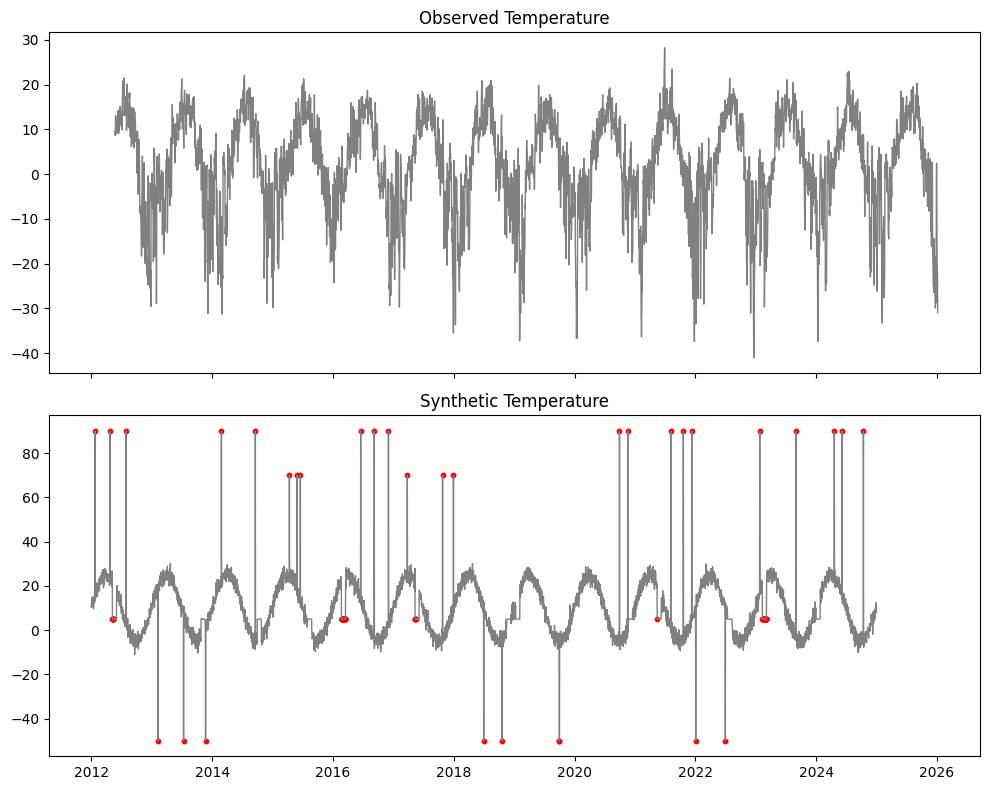

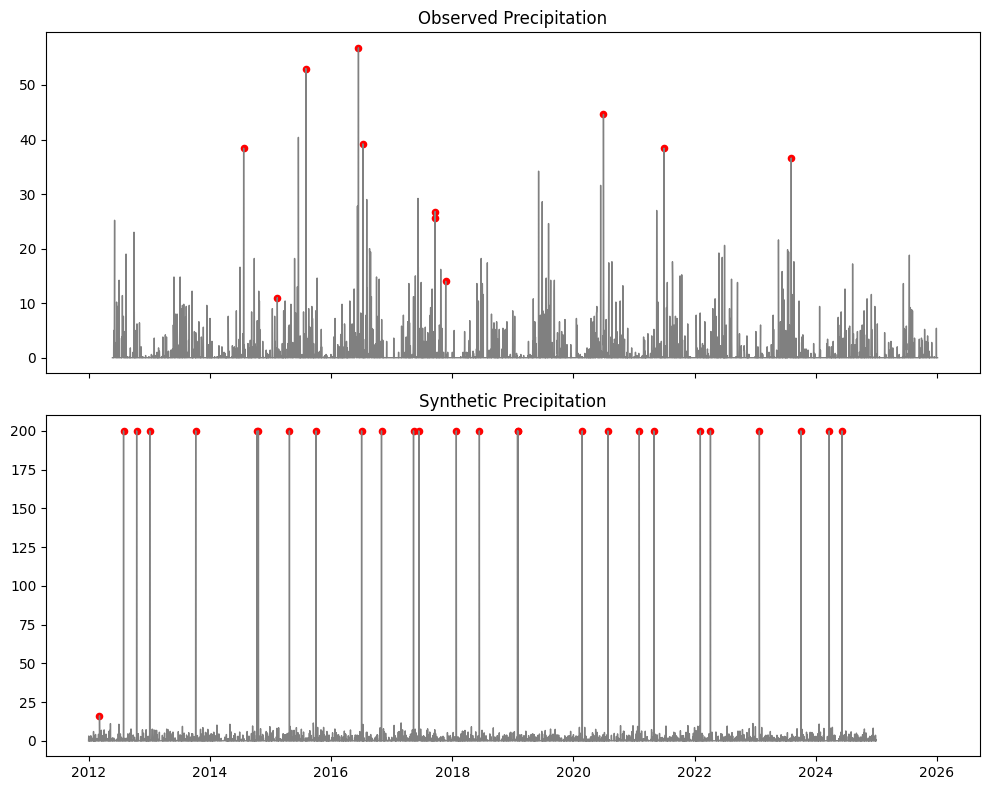

In [132]:
import matplotlib.pyplot as plt


def plot_temp_two_panels(df1, df2, label1="Data1", label2="Data2"):

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # --- Panel 1 ---
    axes[0].plot(df1.index, df1["temp"], color='gray', linewidth=1)
    axes[0].scatter(
        df1.index[df1["temp_flag"]],
        df1["temp"][df1["temp_flag"]],
        color="red", s=10
    )
    axes[0].set_title(f"{label1} Temperature")

    # --- Panel 2 ---
    axes[1].plot(df2.index, df2["temp"], color='gray', linewidth=1)
    axes[1].scatter(
        df2.index[df2["temp_flag"]],
        df2["temp"][df2["temp_flag"]],
        color="red", s=10
    )
    axes[1].set_title(f"{label2} Temperature")

    plt.tight_layout()
    plt.show()


def plot_precip_two_panels(df1, df2, label1="Data1", label2="Data2"):

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # --- Panel 1 ---
    axes[0].plot(df1.index, df1["precip"], color='gray', linewidth=1)
    axes[0].scatter(
        df1.index[df1["precip_flag"]],
        df1["precip"][df1["precip_flag"]],
        color="red", s=20
    )
    axes[0].set_title(f"{label1} Precipitation")

    # --- Panel 2 ---
    axes[1].plot(df2.index, df2["precip"], color='gray', linewidth=1)
    axes[1].scatter(
        df2.index[df2["precip_flag"]],
        df2["precip"][df2["precip_flag"]],
        color="red", s=20
    )
    axes[1].set_title(f"{label2} Precipitation")

    plt.tight_layout()
    plt.show()


plot_temp_two_panels(df_sql_daily, df_test_daily, "Observed", "Synthetic")
plot_precip_two_panels(df_sql_daily, df_test_daily, "Observed", "Synthetic")

In [129]:
def qc_summary(df):

    summary = {
        "Total records": len(df),
        "Temp flagged (%)": df["temp_flag"].mean() * 100,
        "Precip flagged (%)": df["precip_flag"].mean() * 100,
    }

    print(pd.Series(summary))

    return pd.Series(summary)


qc_summary(df_sql_daily)
qc_summary(df_test_daily)

Total records         4975.000000
Temp flagged (%)         0.000000
Precip flagged (%)       0.221106
dtype: float64
Total records         4749.000000
Temp flagged (%)         2.000421
Precip flagged (%)       0.568541
dtype: float64


Total records         4749.000000
Temp flagged (%)         2.000421
Precip flagged (%)       0.568541
dtype: float64